In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('data/klike_challenge_dataset.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    str    
 1   date                 500 non-null    str    
 2   platform             500 non-null    str    
 3   category             500 non-null    str    
 4   objective            500 non-null    str    
 5   target_audience_age  500 non-null    str    
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    str    
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    str    
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int64  
 16  c

In [5]:
df.describe()

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,1.405276e+07,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


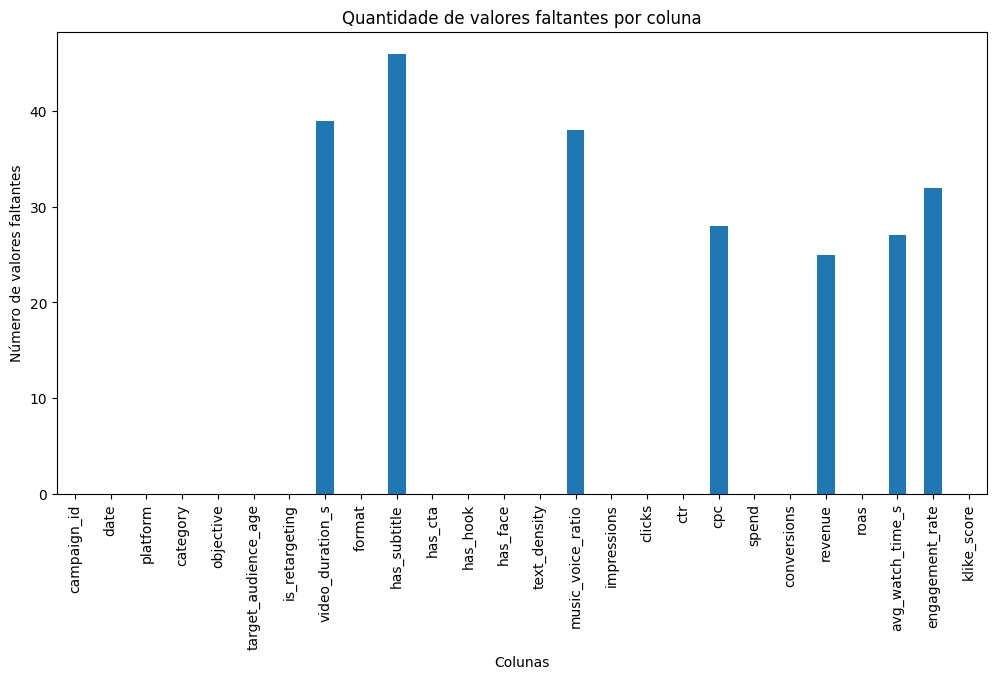

In [6]:
missing_counts = df.isna().sum()

# Plot
plt.figure(figsize=(12,6))
missing_counts.plot(kind='bar')
plt.title("Quantidade de valores faltantes por coluna")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Colunas")
plt.show()

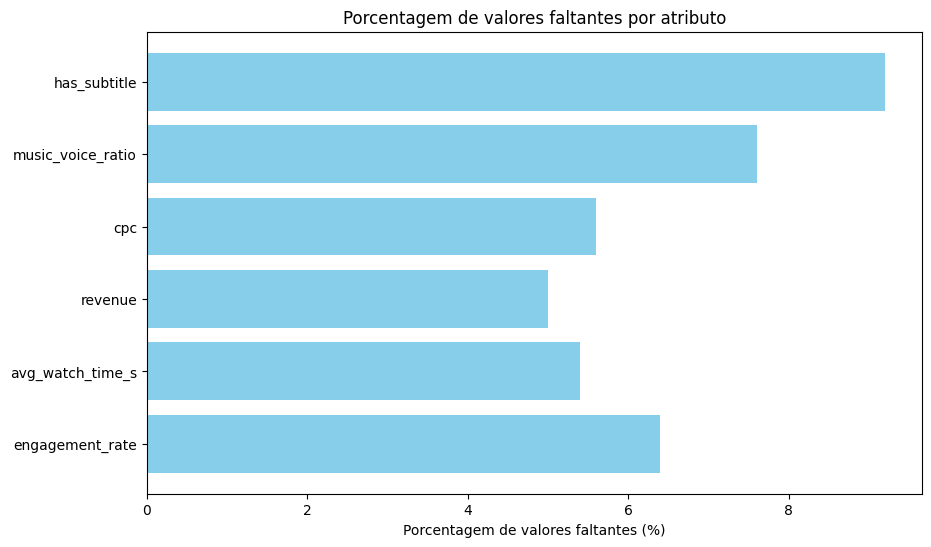

In [7]:
# Lista das colunas e porcentagens
cols = ['has_subtitle', 'music_voice_ratio', 'cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate']
percentages = [9.2, 7.6, 5.6, 5.0, 5.4, 6.4]

plt.figure(figsize=(10,6))
plt.barh(cols, percentages, color='skyblue')
plt.xlabel("Porcentagem de valores faltantes (%)")
plt.title("Porcentagem de valores faltantes por atributo")
plt.gca().invert_yaxis()  # para mostrar do maior para o menor
plt.show()

In [8]:
# Porcentagem de valores faltantes
missing_percent = df.isna().mean() * 100

# Exibir
print(missing_percent)

campaign_id            0.0
date                   0.0
platform               0.0
category               0.0
objective              0.0
target_audience_age    0.0
is_retargeting         0.0
video_duration_s       7.8
format                 0.0
has_subtitle           9.2
has_cta                0.0
has_hook               0.0
has_face               0.0
text_density           0.0
music_voice_ratio      7.6
impressions            0.0
clicks                 0.0
ctr                    0.0
cpc                    5.6
spend                  0.0
conversions            0.0
revenue                5.0
roas                   0.0
avg_watch_time_s       5.4
engagement_rate        6.4
klike_score            0.0
dtype: float64


## Tratamento de valores faltantes

In [9]:
# Qual % é nulo?
df['has_subtitle'].isnull().mean()

# Os nulos têm algum padrão? (ex: só em uma plataforma?)
df[df['has_subtitle'].isnull()]['platform'].value_counts()
df['has_subtitle'] = df['has_subtitle'].fillna(False)

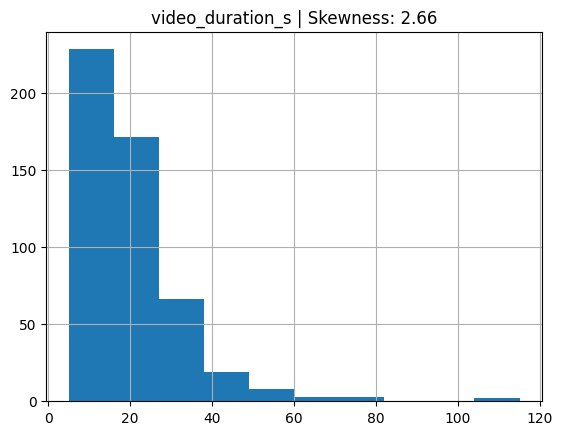

count    500.000000
mean      19.392625
std       12.989894
min        5.000000
25%       11.000000
50%       17.000000
75%       24.000000
max      115.000000
Name: video_duration_s, dtype: float64
Skewness: 2.6605428559073947


In [19]:
# Skewness > 1 -> mediana
skew_val = df['video_duration_s'].skew()

fig, ax = plt.subplots()
df['video_duration_s'].hist(ax=ax)
ax.set_title(f'video_duration_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['video_duration_s'].describe())
print(f"Skewness: {skew_val}")

# Preenche NaNs com a mediana da coluna
df['video_duration_s'] = df['video_duration_s'].fillna(df['video_duration_s'].median())

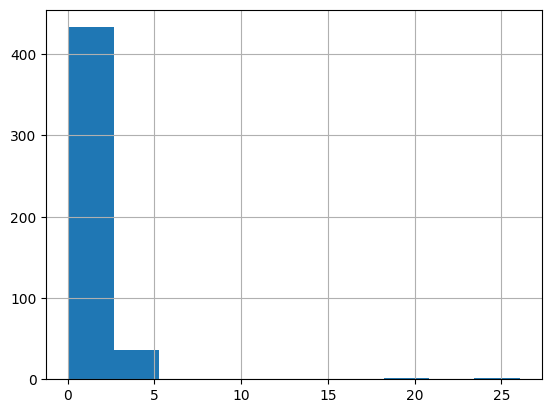

count    472.000000
mean       1.112903
std        1.955625
min        0.050000
25%        0.530000
50%        0.710000
75%        1.020000
max       26.050000
Name: cpc, dtype: float64
Skewness: 9.925325514170042


In [ ]:
skew_val = df['cpc'].skew()

fig, ax = plt.subplots()
df['cpc'].hist(ax=ax)
ax.set_title(f'cpc | Skewness: {skew_val:.2f}')
plt.show()

print(df['cpc'].describe())
print(f"Skewness: {skew_val}")

df['cpc'] = df['cpc'].fillna(df['cpc'].median())

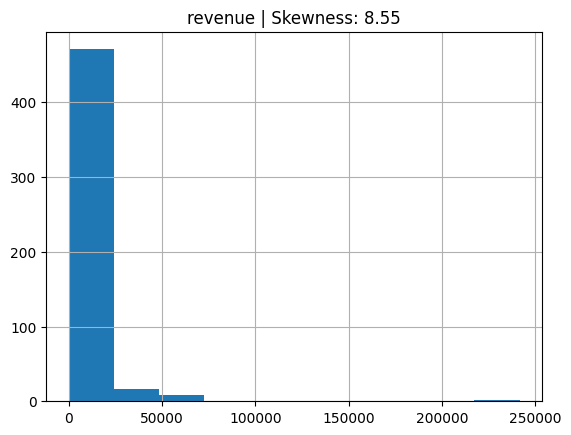

count       500.000000
mean       6109.592520
std       18812.136455
min           0.000000
25%         288.595000
50%        1201.050000
75%        4009.365000
max      241597.290000
Name: revenue, dtype: float64
Skewness: 8.552768456748144


In [20]:
skew_val = df['revenue'].skew()

fig, ax = plt.subplots()
df['revenue'].hist(ax=ax)
ax.set_title(f'revenue | Skewness: {skew_val:.2f}')
plt.show()

print(df['revenue'].describe())
print(f"Skewness: {skew_val}")

df['revenue'] = df['revenue'].fillna(df['revenue'].median())

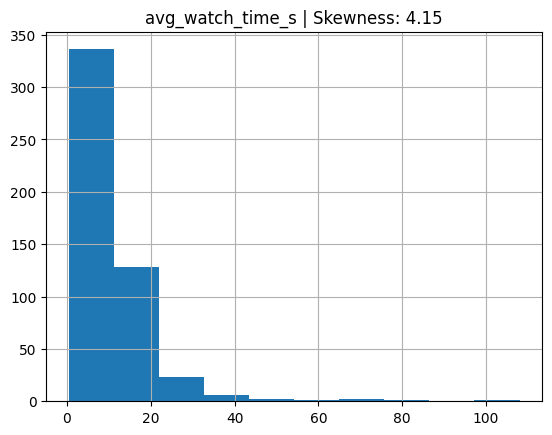

count    500.000000
mean      10.504200
std       10.266273
min        0.400000
25%        4.800000
50%        7.700000
75%       13.300000
max      108.000000
Name: avg_watch_time_s, dtype: float64
Skewness: 4.145865906039796


In [21]:
skew_val = df['avg_watch_time_s'].skew()

fig, ax = plt.subplots()
df['avg_watch_time_s'].hist(ax=ax)
ax.set_title(f'avg_watch_time_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['avg_watch_time_s'].describe())
print(f"Skewness: {skew_val}")

df['avg_watch_time_s'] = df['avg_watch_time_s'].fillna(df['avg_watch_time_s'].median())

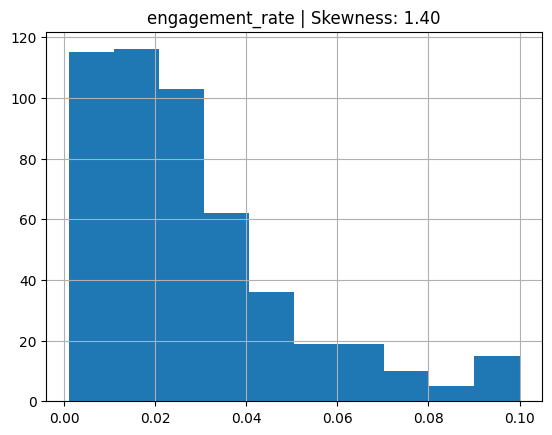

count    500.000000
mean       0.027533
std        0.022363
min        0.001000
25%        0.011875
50%        0.021400
75%        0.037750
max        0.100000
Name: engagement_rate, dtype: float64
Skewness: 1.395447472642172


In [22]:
skew_val = df['engagement_rate'].skew()

fig, ax = plt.subplots()
df['engagement_rate'].hist(ax=ax)
ax.set_title(f'engagement_rate | Skewness: {skew_val:.2f}')
plt.show()

print(df['engagement_rate'].describe())
print(f"Skewness: {skew_val}")

df['engagement_rate'] = df['engagement_rate'].fillna(df['engagement_rate'].median())

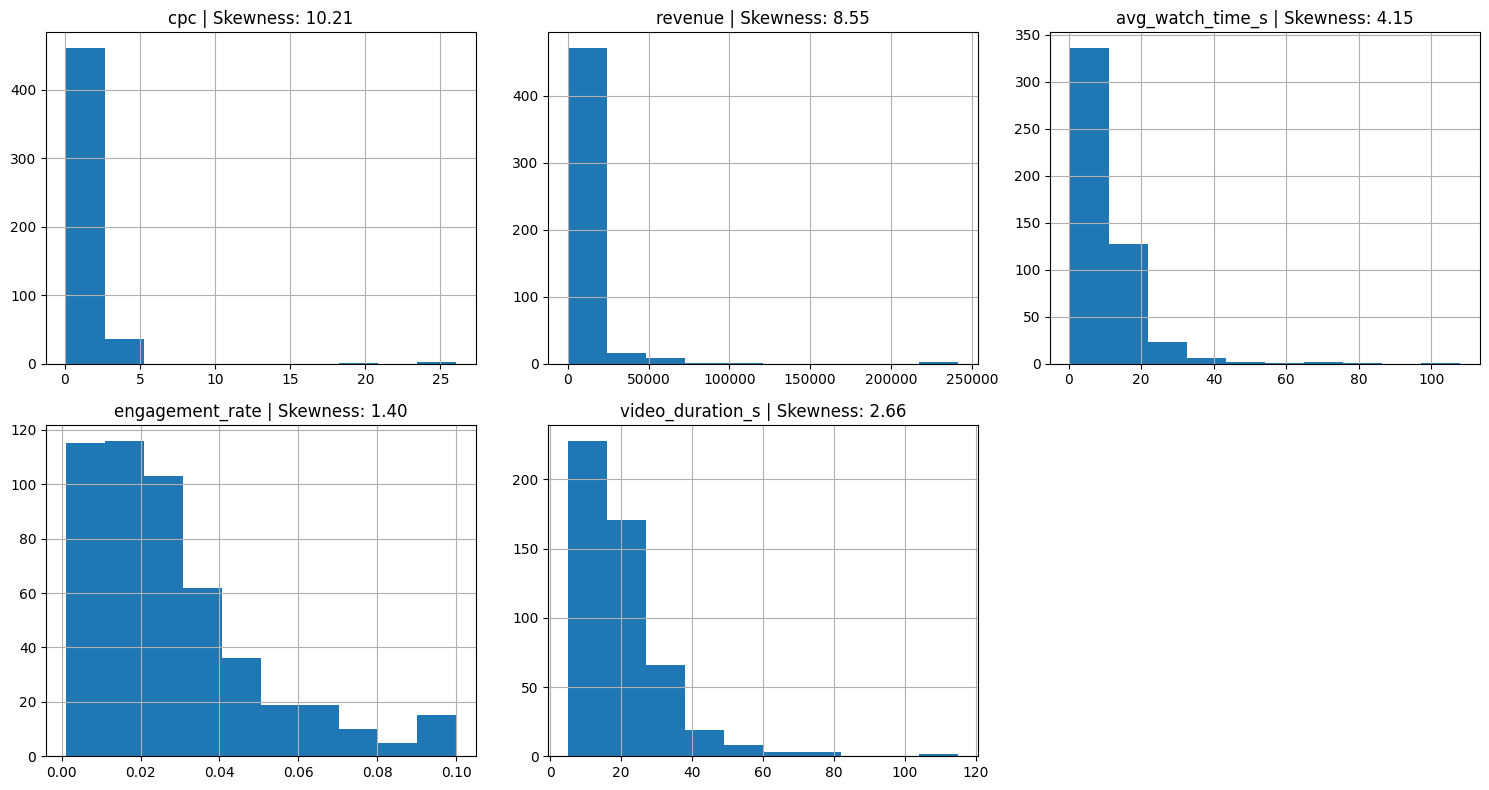

In [23]:
cols = ['cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate', 'video_duration_s']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    skew_val = df[col].skew()
    df[col].hist(ax=axes[i])
    axes[i].set_title(f'{col} | Skewness: {skew_val:.2f}')

axes[-1].set_visible(False)  # esconde o subplot vazio
plt.tight_layout()
plt.show()

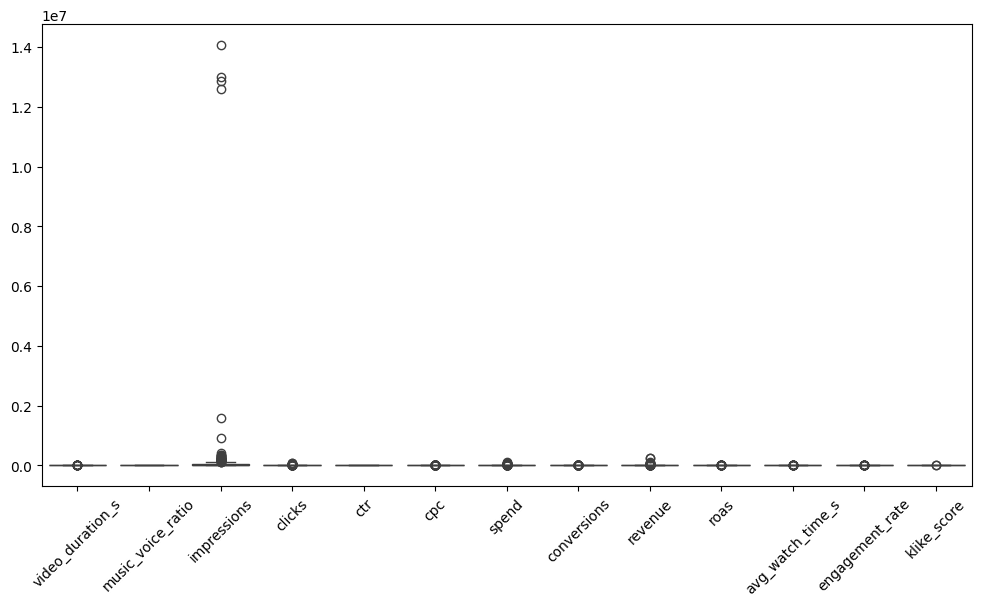

In [111]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

Colunas com maior diferença de magnitude: ['impressions', 'revenue', 'spend', 'clicks', 'conversions', 'video_duration_s']


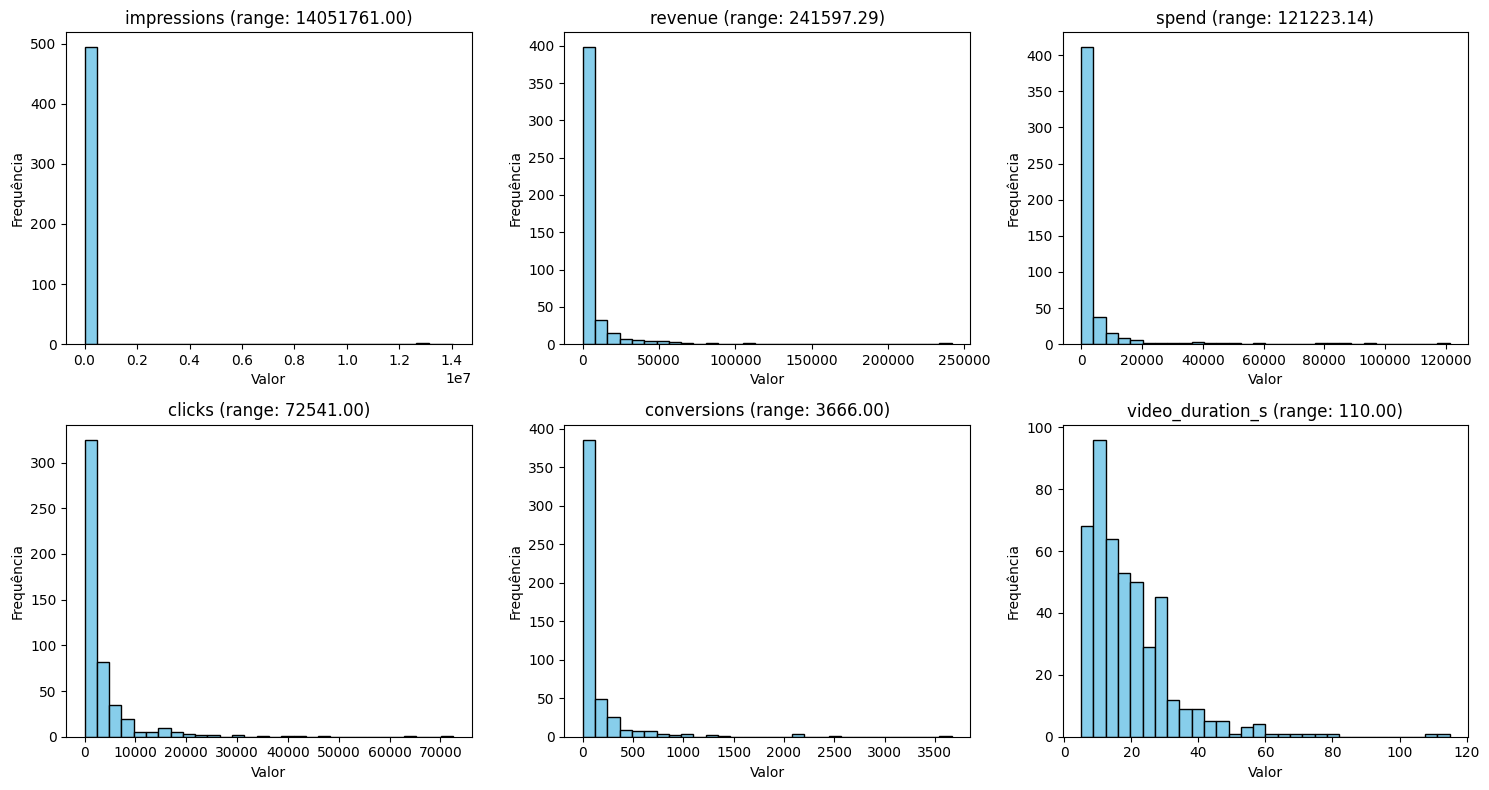

In [110]:
atributos = df.select_dtypes(include='number').columns

# Calcula a diferença entre máximo e mínimo
ranges = df[atributos].max() - df[atributos].min()

# Seleciona as top N colunas com maior diferença
top_n = 6
top_atributos = ranges.sort_values(ascending=False).head(top_n).index
print("Colunas com maior diferença de magnitude:", list(top_atributos))
n = len(top_atributos)
cols_subplot = 3
rows_subplot = math.ceil(n / cols_subplot)

plt.figure(figsize=(5*cols_subplot, 4*rows_subplot))
for i, col in enumerate(top_atributos, 1):
    plt.subplot(rows_subplot, cols_subplot, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (range: {ranges[col]:.2f})")
    plt.xlabel("Valor")
    plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

In [112]:
df['impressions_lg'] = np.log1p(df['impressions'])
df['clicks_lg'] = np.log1p(df['clicks'])

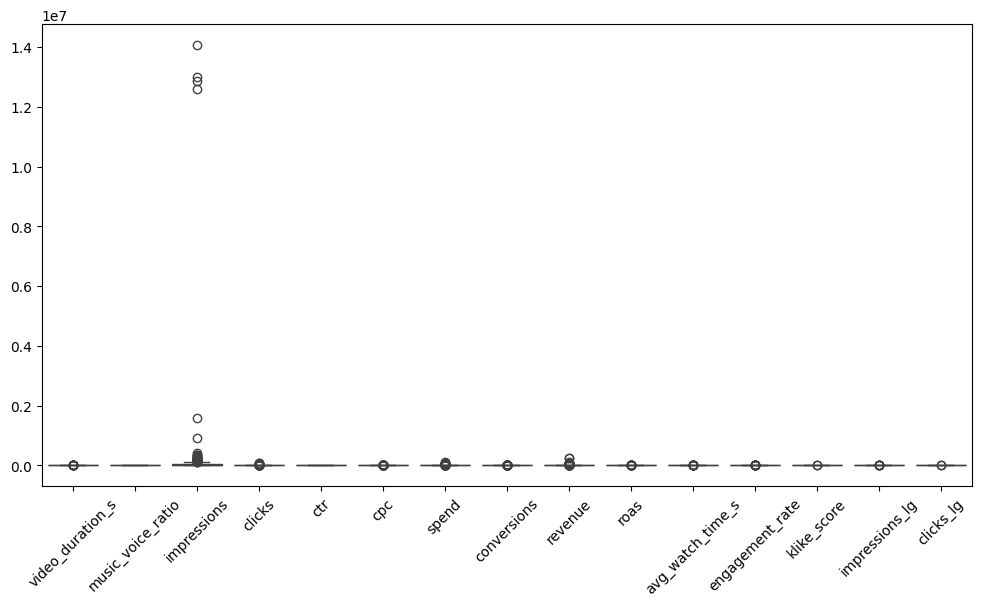

In [113]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [114]:
scaler = MinMaxScaler()
df[['spend_norm','revenue_norm','conversions_norm']] = scaler.fit_transform(df[['spend','revenue','conversions']])

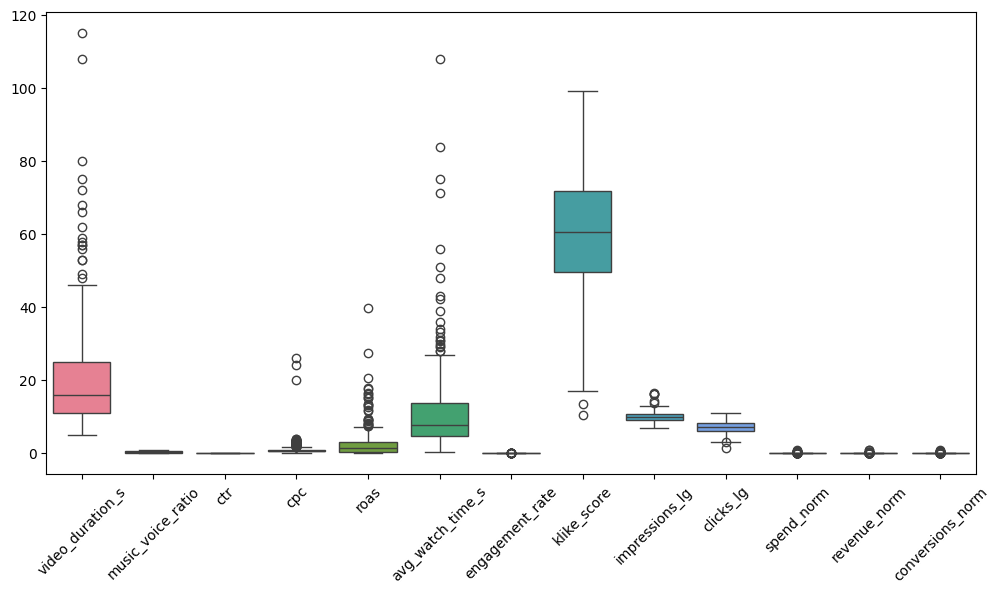

In [116]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

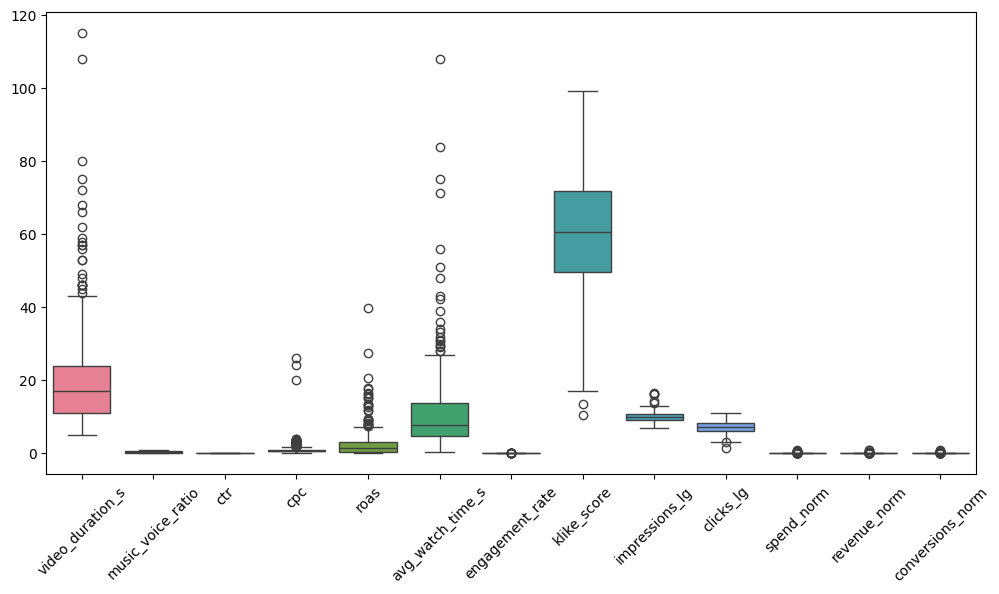

In [118]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [26]:
df[df['avg_watch_time_s'] > df['video_duration_s']]

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,...,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
91,KLK-0092,2024-02-18,TikTok,App Install,traffic,18-24,False,5.000000,vertical,True,...,65,0.0114,0.44,28.60,2,17.18,0.60,7.7,0.0304,49.9
113,KLK-0114,2024-11-01,TikTok,E-commerce,traffic,25-34,True,6.000000,vertical,True,...,162,0.0738,0.43,69.66,21,1048.14,15.05,7.7,0.0274,72.0
117,KLK-0118,2024-03-16,Meta,E-commerce,conversions,45+,True,5.000000,vertical,False,...,5455,0.1500,0.54,2945.70,408,18972.39,6.44,7.7,0.0214,62.4
154,KLK-0155,2024-04-13,LinkedIn,SaaS,awareness,45+,True,19.392625,vertical,True,...,13479,0.1168,3.40,45828.60,518,57811.62,1.26,25.7,0.0102,69.0
252,KLK-0253,2024-06-30,LinkedIn,App Install,traffic,45+,True,19.392625,quadrado,False,...,6663,0.0907,3.31,22054.53,433,4541.91,0.21,84.0,0.0172,66.4
287,KLK-0288,2024-12-17,TikTok,SaaS,conversions,25-34,False,6.000000,vertical,False,...,142,0.0565,0.44,62.48,3,317.71,5.08,7.7,0.0130,59.0
369,KLK-0370,2024-12-16,Meta,Lead Gen,engagement,35-44,True,19.392625,quadrado,True,...,129,0.0216,0.89,114.81,5,273.22,2.38,22.0,0.0125,56.7
